 # **Import Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import shapiro, f_oneway, stats
from statsmodels.stats.multicomp import MultiComparison
from yellowbrick.regressor import ResidualsPlot


Mounted at /content/drive


 # **Regression algorithms for farm areas**





In [2]:
# Load data
all_areas_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/output/final/data_integration_all_areas_final.csv")


In [3]:
all_areas_df.select_dtypes(include=['int64','float64'])


,index,farm,area_cod,area_size,CO2_emission_area,CO2_emission_ha,CO2_stock_area,CO2_stock_ha,balance_CO2_area,balance_CO2_ha,city_cod,state_cod,biome_cod,climate_cod,year
0,1,4576327,3,5.35,0.000000,0.000000,167.718896,31.349326,167.718896,31.349326,1100908,11,1,2,2021
1,2,4576327,12,0.27,1.996577,7.394729,8.463050,31.344631,6.466474,23.949902,1100908,11,1,2,2021
2,3,4576327,15,69.79,516.078138,7.394729,2044.337396,29.292698,1528.259257,21.897969,1100908,11,1,2,2021
3,4,4574927,3,3.23,0.000000,0.000000,101.258324,31.349326,101.258324,31.349326,1100908,11,1,2,2021
4,5,4574927,12,0.30,2.218419,7.394729,9.403389,31.344631,7.184971,23.949902,1100908,11,1,2,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22795,22796,13894,12,0.08,0.394706,4.933824,2.159577,26.994707,1.764871,22.060882,2312908,23,2,3,2021
22796,22797,4749410,3,2.08,0.000000,0.000000,76.117710,36.595053,76.117710,36.595053,2312908,23,2,3,2021
22797,22798,4749410,4,82.95,0.000000,0.000000,2347.975103,28.305908,2347.975103,28.305908,2312908,23,2,3,2021
22798,22799,4749410,12,0.68,3.355000,4.933824,18.356401,26.994707,15.001400,22.060882,2312908,23,2,3,2021


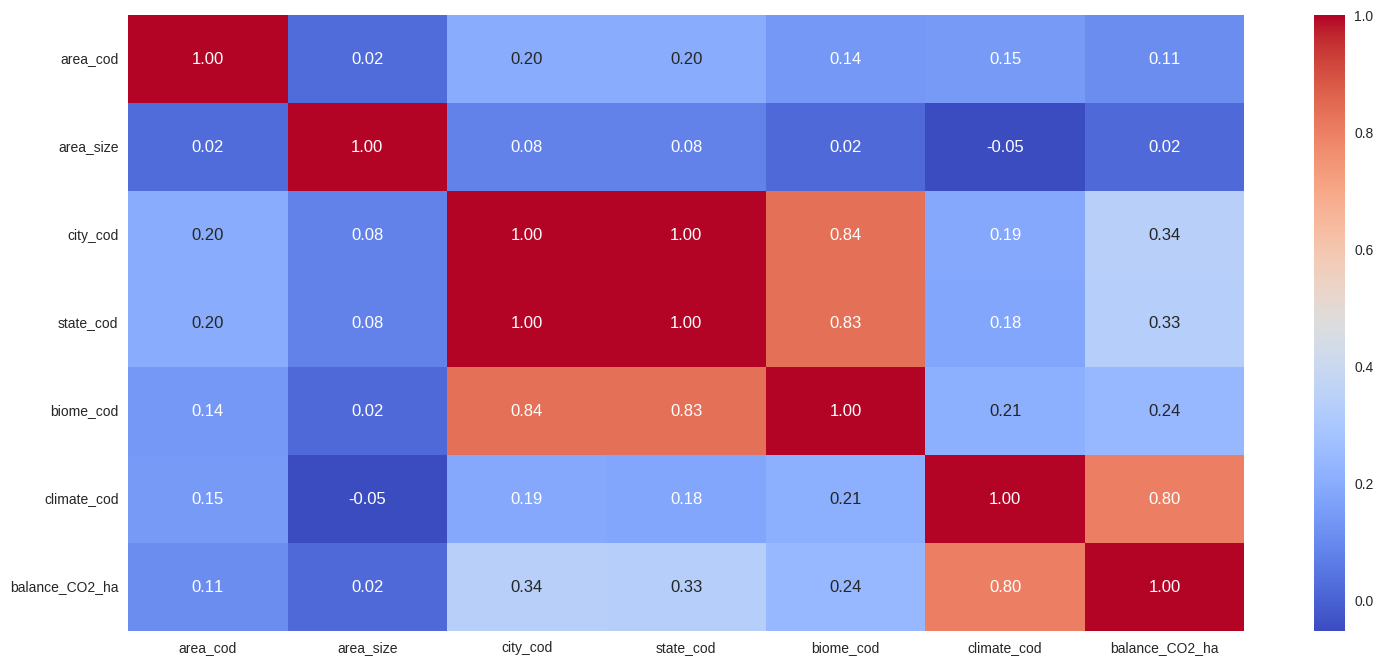

In [4]:

# 🚀 SETUP GLOBAL PARA xAI E PREVENÇÃO DE VAZAMENTO DE DADOS
features_xai = [
    'area_cod',     # Uso do Solo
    'area_size',    # Tamanho da Área
    'city_cod',     # Cidade
    'state_cod',    # Estado
    'biome_cod',    # Bioma
    'climate_cod'   # Clima
]
target = 'balance_CO2_ha'

# Correlation APENAS com as features permitidas e o target (Sem Data Leakage)
colunas_correlacao = features_xai + [target]
all_areas_df_corr = all_areas_df[colunas_correlacao]

figura = plt.figure(figsize=(18,8))
sns.heatmap(all_areas_df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


In [5]:
all_areas_df.count()


,0
index,22800
farm,22800
area_cod,22800
area_name,22800
area_size,22800
CO2_emission_area,22800
CO2_emission_ha,22800
CO2_stock_area,22800
CO2_stock_ha,22800
balance_CO2_area,22800


 #**Linear Regression - Simple**

In [6]:
# X is the single predictor attribute: climate_cod
X_areas = all_areas_df['climate_cod'].values
X_areas


array([2, 2, 2, ..., 3, 3, 3])

In [7]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df[target].values
Y_areas


array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

In [8]:
X_areas.shape, Y_areas.shape


((22800,), (22800,))

In [9]:
# Correlation coefficient
np.corrcoef(X_areas, Y_areas)


array([[1.        , 0.80127047],
       [0.80127047, 1.        ]])

In [10]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas


array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [11]:
X_areas.shape


(22800, 1)

 **Simple Linear Regression - training and testing bases**

In [12]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)


In [13]:
X_areas_trein.shape, Y_areas_trein.shape, X_areas_test.shape, Y_areas_test.shape


((17100, 1), (17100,), (5700, 1), (5700,))



 **Standardization, if necessary**

In [14]:
# We fit and transform the training set, but only transform the test set 
# using the exact parameters (mean and variance) learned from the training data.
scaler_areas_x = StandardScaler()
X_areas_trein = scaler_areas_x.fit_transform((X_areas_trein).reshape(-1,1))
X_areas_test = scaler_areas_x.transform((X_areas_test).reshape(-1,1))

scaler_areas_y = StandardScaler()
Y_areas_trein = scaler_areas_y.fit_transform((Y_areas_trein).reshape(-1,1))
Y_areas_test = scaler_areas_y.transform((Y_areas_test).reshape(-1,1))

X_areas_trein, Y_areas_trein, X_areas_test, Y_areas_test



(array([[ 2.04293687],
        [ 2.04293687],
        [-0.33024732],
        ...,
        [-0.33024732],
        [-0.33024732],
        [ 2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 0.61902636],
        [ 2.04293687],
        [-0.33024732],
        ...,
        [ 2.04293687],
        [-0.33024732],
        [-0.80488415]]),
 array([[ 0.7564848 ],
        [ 1.33939139],
        [-0.00878267],
        ...,
        [ 1.24779181],
        [-0.43073256],
        [-1.44795368]]))

 **Regression Model for training**

In [15]:
# Convert array to matrix
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein


array([[ 2.04293687],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [-0.33024732],
       [-0.33024732],
       [ 2.04293687]])

In [16]:
# Create the regression model (trein)
simple_linear_regressor_trein = LinearRegression()
simple_linear_regressor_trein.fit(X_areas_trein, Y_areas_trein)


LinearRegression()

In [17]:
# score: algorithm quality metric (trein)
simple_linear_regressor_trein.score(X_areas_trein, Y_areas_trein)


0.6402051597659755

In [18]:
# Prevision (trein)
prevision_simple_linear_regressor_trein = simple_linear_regressor_trein.predict(X_areas_trein)
prevision_simple_linear_regressor_trein


array([[ 1.63461143],
       [ 1.63461143],
       [-0.26424019],
       ...,
       [-0.26424019],
       [-0.26424019],
       [ 1.63461143]])

In [19]:
# Real data
Y_areas_trein


array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [20]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_simple_linear_regressor_trein)


0.46766654955311804

In [21]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein)


0.35979484023402447

In [22]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein))


np.float64(0.5998290091634653)

In [23]:
# Prediction with a standardized climate code (value 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + scaler_areas_x.transform([[15]])[0][0]


array([4.8907579])

 **Regression Model for testing**

In [24]:
# Convert array to matrix
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test


array([[ 0.61902636],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [ 2.04293687],
       [-0.33024732],
       [-0.80488415]])

In [25]:
# score: algorithm quality metric (test)
simple_linear_regressor_trein.score(X_areas_test, Y_areas_test)


0.6474472065351384

In [26]:
# Prevision (test)
prevision_simple_linear_regressor_test = simple_linear_regressor_trein.predict(X_areas_test)
prevision_simple_linear_regressor_test


array([[ 0.49530046],
       [ 1.63461143],
       [-0.26424019],
       ...,
       [ 1.63461143],
       [-0.26424019],
       [-0.64401052]])

In [27]:
# Real data
Y_areas_test


array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [28]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_simple_linear_regressor_test)


0.46201992579723833

In [29]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test)


0.34606305802644727

In [30]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test))


np.float64(0.5882712452826904)

In [31]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + scaler_areas_x.transform([[15]])[0][0]


array([4.8907579])

 # **Linear Regression - Multiple**

In [32]:
# X matrix composed of the 6 multi-criteria features (area code, Size, City, State, Biome, Climate)
X_areas_mult = all_areas_df[features_xai].values
X_areas_mult


array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [33]:
# # Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df[target].values
Y_areas_mult


array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

 **Multiple Linear Regression - training and testing bases**

In [34]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)


In [35]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape


((17100, 6), (17100,), (5700, 6), (5700,))

 **Standardization, if necessary**



In [36]:
scaler_areas_x_mult = StandardScaler()
X_areas_mult_trein = scaler_areas_x_mult.fit_transform((X_areas_mult_trein))
X_areas_mult_test = scaler_areas_x_mult.transform((X_areas_mult_test)) 

scaler_areas_y_mult = StandardScaler()
Y_areas_mult_trein = scaler_areas_y_mult.fit_transform((Y_areas_mult_trein).reshape(-1, 1)) 
Y_areas_mult_test = scaler_areas_y_mult.transform((Y_areas_mult_test).reshape(-1, 1))

X_areas_mult_trein, Y_areas_mult_trein, X_areas_mult_test, Y_areas_mult_test


(array([[ 0.41451135, -0.15136168, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [ 0.41451135, -0.16520356, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [ 0.41451135,  1.90797261,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        ...,
        [-0.07364724,  5.29032881,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        [-0.07364724, -0.13627713,  0.92012512,  0.92456378,  1.25012909,
         -0.33024732],
        [ 0.41451135, -0.08802038, -0.47463678, -0.49368236, -0.44503961,
          2.04293687]]),
 array([[ 1.33939139],
        [ 1.33939139],
        [-0.43073256],
        ...,
        [-0.68259947],
        [-0.68259947],
        [ 1.33939139]]),
 array([[ 2.04170663, -0.16440964,  0.36108383,  0.35726532,  0.68507286,
          0.61902636],
        [ 0.41451135, -0.16444416, -0.47463678, -0.49368236, -0.44503961,
          2.04293687],
        [-0.96860464, -0.15433026,  0.92024292,  0.92456

 **Regression Model for training**

In [37]:
# Create the regression model (trein)
mult_linear_regressor_trein = LinearRegression()
mult_linear_regressor_trein.fit(X_areas_mult_trein, Y_areas_mult_trein)


LinearRegression()

In [38]:
# score: algorithm quality metric (trein)
mult_linear_regressor_trein.score(X_areas_mult_trein, Y_areas_mult_trein)


0.7440919786026767

In [39]:
# Prevision (trein)
prevision_mult_linear_regressor_trein = mult_linear_regressor_trein.predict(X_areas_mult_trein)
prevision_mult_linear_regressor_trein


array([[ 1.47308489],
       [ 1.47263003],
       [-0.20198712],
       ...,
       [-0.05431278],
       [-0.232637  ],
       [ 1.47516636]])

In [40]:
# Real data
Y_areas_mult_trein


array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [41]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)


0.40285018862148314

In [42]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)


0.2559080213973232

In [43]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein))


np.float64(0.5058735231234416)

 **Regression Model for testing**

In [44]:
# score: algorithm quality metric (test)
mult_linear_regressor_trein.score(X_areas_mult_test, Y_areas_mult_test)


0.7447778959678222

In [45]:
# Prevision (test)
prevision_mult_linear_regressor_test = mult_linear_regressor_trein.predict(X_areas_mult_test)
prevision_mult_linear_regressor_test


array([[ 0.39943652],
       [ 1.47265499],
       [ 0.41376057],
       ...,
       [ 1.5092642 ],
       [-0.26883673],
       [-1.18996324]])

In [46]:
# Real data
Y_areas_mult_test


array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [47]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)


0.40035918899141537

In [48]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)


0.2505240163587656

In [49]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test))


np.float64(0.5005237420530275)

 # **Polynomial Regression**

In [50]:
# X is the single predictor feature: climate_cod
X_areas = all_areas_df['climate_cod'].values
X_areas


array([2, 2, 2, ..., 3, 3, 3])

In [51]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df[target].values
Y_areas


array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

 **Polynomial Linear Regression - training and testing bases**

In [52]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)


In [53]:
scaler_polynomial_x = StandardScaler()
X_areas_trein  = scaler_polynomial_x.fit_transform(X_areas_trein.reshape(-1,1))
X_areas_test = scaler_polynomial_x.transform(X_areas_test.reshape(-1,1))

scaler_polynomial_y = StandardScaler()
Y_areas_trein  = scaler_polynomial_y.fit_transform(Y_areas_trein.reshape(-1,1))
Y_areas_test = scaler_polynomial_y.transform(Y_areas_test.reshape(-1,1))



In [54]:
# Apply degree to the polynomial
polynomial_degree = PolynomialFeatures(degree=2) 


 **Regression Model for training**

In [55]:
X_areas_trein.shape, Y_areas_trein.shape


((17100, 1), (17100, 1))

In [56]:
# Transforming array into matrix (required for sklearn)
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein


array([[ 2.04293687],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [-0.33024732],
       [-0.33024732],
       [ 2.04293687]])

In [57]:
# Apply polynominal degree in X
X_areas_trein_poly = polynomial_degree.fit_transform(X_areas_trein)
X_areas_trein_poly.shape


(17100, 3)

In [58]:
# Create the regression model
poly_simple_linear_regressor_trein = LinearRegression()
poly_simple_linear_regressor_trein.fit(X_areas_trein_poly, Y_areas_trein)


LinearRegression()

In [59]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_trein.score(X_areas_trein_poly, Y_areas_trein)


0.650252795793373

In [60]:
# Prevision
prevision_poly_simple_linear_regressor_trein = poly_simple_linear_regressor_trein.predict(X_areas_trein_poly)
prevision_poly_simple_linear_regressor_trein


array([[ 1.51136156],
       [ 1.51136156],
       [-0.207015  ],
       ...,
       [-0.207015  ],
       [-0.207015  ],
       [ 1.51136156]])

In [61]:
# Real data
Y_areas_trein


array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [62]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)


0.4498088679114038

In [63]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)


0.3497472042066268

In [64]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein))


np.float64(0.5913942882769725)

 **Regression Model for testing**

In [65]:
X_areas_test.shape, Y_areas_test.shape


((5700, 1), (5700, 1))

In [66]:
# Transforming array into matrix (required for sklearn)
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test


array([[ 0.61902636],
       [ 2.04293687],
       [-0.33024732],
       ...,
       [ 2.04293687],
       [-0.33024732],
       [-0.80488415]])

In [67]:
# Apply polynominal degree in X
X_areas_test_poly = polynomial_degree.transform(X_areas_test) 
X_areas_test_poly.shape


(5700, 3)

In [68]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_trein.score(X_areas_test_poly, Y_areas_test)


0.6590801343088739

In [69]:
# Prevision
prevision_poly_simple_linear_regressor_test = poly_simple_linear_regressor_trein.predict(X_areas_test_poly)
prevision_poly_simple_linear_regressor_test


array([[ 0.61375079],
       [ 1.51136156],
       [-0.207015  ],
       ...,
       [ 1.51136156],
       [-0.207015  ],
       [-0.68410548]])

In [70]:
# Real data
Y_areas_test


array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [71]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)


0.4416265902629157

In [72]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)


0.33464426732671926

In [73]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test))


np.float64(0.5784844572905302)

 # **Polynomial Regression - Multiple**

In [74]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_mult = all_areas_df[features_xai].values
X_areas_mult


array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [75]:
# Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df[target].values
Y_areas_mult


array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

 **Multiple Linear Regression - training and testing bases**

In [76]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)


In [77]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape


((17100, 6), (17100,), (5700, 6), (5700,))

In [78]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=2) 


 **Standardization, in this algorithm is very important**

In [79]:
scaler_mult_polynomial_x = StandardScaler()
X_areas_mult_trein  = scaler_mult_polynomial_x.fit_transform(X_areas_mult_trein)
X_areas_mult_test = scaler_mult_polynomial_x.transform(X_areas_mult_test)

scaler_mult_polynomial_y = StandardScaler()
Y_areas_mult_trein = scaler_mult_polynomial_y.fit_transform(Y_areas_mult_trein.reshape(-1, 1))
Y_areas_mult_test = scaler_mult_polynomial_y.transform(Y_areas_mult_test.reshape(-1, 1))



 **Regression Model for training**

In [80]:
# Apply polynominal degree in X
X_areas_multi_poly_trein = mult_polynomial_degree.fit_transform(X_areas_mult_trein)


In [81]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    poly = LinearRegression()
    scores = cross_val_score(poly, X_areas_multi_poly_trein, Y_areas_mult_trein, cv=kfold)
    results_polynomial.append(scores.mean())



In [82]:
# Create the regression model (for trein data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_trein, Y_areas_mult_trein)


LinearRegression()

In [83]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_trein , Y_areas_mult_trein)


0.8819054745288298

In [84]:
# Prevision
prevision_poly_mult_linear_regressor_trein = poly_mult_linear_regressor.predict(X_areas_multi_poly_trein)
prevision_poly_mult_linear_regressor_trein


array([[ 1.23867364],
       [ 1.24501898],
       [-0.46904363],
       ...,
       [-0.26197955],
       [-0.40165177],
       [ 1.2096314 ]])

In [85]:
# Real data
Y_areas_mult_trein


array([[ 1.33939139],
       [ 1.33939139],
       [-0.43073256],
       ...,
       [-0.68259947],
       [-0.68259947],
       [ 1.33939139]])

In [86]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)


0.2538457610625985

In [87]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)


0.11809452547117018

In [88]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein))


np.float64(0.3436488403460285)



 **Regression Model for testing**

In [89]:
# Apply polynominal degree in X
X_areas_multi_poly_test = mult_polynomial_degree.transform(X_areas_mult_test) 


In [90]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_test , Y_areas_mult_test)


0.8821847816625706

In [91]:
# Prevision
prevision_poly_mult_linear_regressor_test = poly_mult_linear_regressor.predict(X_areas_multi_poly_test)
prevision_poly_mult_linear_regressor_test


array([[ 0.59783036],
       [ 1.24467087],
       [ 0.05511831],
       ...,
       [ 1.34921069],
       [-0.54619392],
       [-1.36117271]])

In [92]:
# Real Data
Y_areas_mult_test


array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [93]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)


0.2504763745976724

In [94]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)


0.11564649464043465

In [95]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test))


np.float64(0.3400683675975092)

 # **Decision Tree Regression**

In [96]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree = all_areas_df[['area_cod']].values
X_areas_tree


array([[ 3],
       [12],
       [15],
       ...,
       [ 4],
       [12],
       [15]])

In [97]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree  = all_areas_df[target].values
Y_areas_tree



array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

 **Decision Tree Regression - training and testing bases**

In [98]:
# Division of bases (75% trein, 25% test)
X_areas_tree_trein, X_areas_tree_test, Y_areas_tree_trein, Y_areas_tree_test = train_test_split(X_areas_tree, Y_areas_tree, test_size = 0.25, random_state = 0)
X_areas_tree_trein.shape, Y_areas_tree_trein.shape, X_areas_tree_test.shape, Y_areas_tree_test.shape


((17100, 1), (17100,), (5700, 1), (5700,))

 **Decision Tree for training**

In [99]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_trein, Y_areas_tree_trein)


DecisionTreeRegressor()

In [100]:
# Prevision
prevision_areas_tree_trein = regressor_areas_tree.predict(X_areas_tree_trein)
prevision_areas_tree_trein[:10]


array([35.67371324, 35.67371324, 35.67371324, 34.03334075, 29.90336477,
       35.67371324, 35.67371324, 35.67371324, 40.64426883, 29.90336477])

In [101]:
Y_areas_tree_trein[:10]


array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [102]:
# Score
regressor_areas_tree.score(X_areas_tree_trein,Y_areas_tree_trein)


0.258375460165821

In [103]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_trein, prevision_areas_tree_trein)


6.465009972315875

In [104]:
# Mean squared error
mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein)


67.040750530816

In [105]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein))


np.float64(8.187841628342357)



 **Decision Tree for testing**

In [106]:
# Prevision
prevision_areas_tree_test = regressor_areas_tree.predict(X_areas_tree_test)
prevision_areas_tree_test[:10]


array([35.76634525, 35.67371324, 32.87159106, 34.03334075, 32.87159106,
       40.25314972, 35.76634525, 32.87159106, 35.67371324, 29.90336477])

In [107]:
Y_areas_tree_test[:10]


array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [108]:
# Score
regressor_areas_tree.score(X_areas_tree_test,Y_areas_tree_test)


0.25358880028851516

In [109]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_test, prevision_areas_tree_test)


6.459532175193367

In [110]:
# Mean squared error
mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test)


66.23141048431235

In [111]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test))


np.float64(8.138268273061065)

 # Decision Tree Regression - **Multiple**

In [112]:
# X composed of attributes: area_cod, city_cod, climate_cod (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree_mult = all_areas_df[features_xai].values
X_areas_tree_mult


array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [113]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree_mult  = all_areas_df[target].values.reshape(-1, 1)
Y_areas_tree_mult



array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

 **Multiple Decision Tree Regression - training and testing bases**

In [114]:
# # Division of bases (75% trein, 25% test)
X_areas_tree_mult_trein, X_areas_tree_mult_test, Y_areas_tree_mult_trein, Y_areas_tree_mult_test = train_test_split(X_areas_tree_mult, Y_areas_tree_mult, test_size = 0.25, random_state = 0)
X_areas_tree_mult_trein.shape, Y_areas_tree_mult_trein.shape, X_areas_tree_mult_test.shape, Y_areas_tree_mult_test.shape


((17100, 6), (17100, 1), (5700, 6), (5700, 1))

 **Multiple Decision Tree for training**

In [115]:
regressor_areas_tree_mult_trein = DecisionTreeRegressor()
regressor_areas_tree_mult_trein.fit(X_areas_tree_mult_trein, Y_areas_tree_mult_trein)


DecisionTreeRegressor()

In [116]:
prevision_area_tree_mult_trein = regressor_areas_tree_mult_trein.predict(X_areas_tree_mult_trein)
prevision_area_tree_mult_trein[:10]


array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [117]:
Y_areas_tree_mult_trein[:10].ravel()


array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [118]:
# Score
regressor_areas_tree_mult_trein.score(X_areas_tree_mult_trein,Y_areas_tree_mult_trein)


1.0

In [119]:
# Predict a new value
regressor_areas_tree_mult_trein.predict([[46, 150.0, 3161403, 31, 6, 8]])



array([58.66131494])

In [120]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)


3.4220132900170735e-13

In [121]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)


1.803893048172309e-25

In [122]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein))



np.float64(4.2472262103310546e-13)

In [123]:
# Cross Validation Decision Tree Regression - Trein(Multiple)
results_tree_trein = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    tree = DecisionTreeRegressor()
    scores = cross_val_score(tree, X_areas_tree_mult_trein, Y_areas_tree_mult_trein, cv=kfold)
    results_tree_trein.append(scores.mean())


 **Multiple Decision Tree for testing**

In [124]:
prevision_area_tree_mult_test = regressor_areas_tree_mult_trein.predict(X_areas_tree_mult_test)
prevision_area_tree_mult_test[:10]


array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [125]:
Y_areas_tree_mult_test[:10].ravel()


array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [126]:
# Score
regressor_areas_tree_mult_trein.score(X_areas_tree_mult_test,Y_areas_tree_mult_test)


1.0

In [127]:
regressor_areas_tree_mult_trein.predict([[46, 150.0, 3161403, 31, 6, 8]])


array([58.66131494])

In [128]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)


3.4667193092804825e-13

In [129]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)


1.8503005228718068e-25

In [130]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test))


np.float64(4.3015119700772737e-13)

 # **Random Forest Regression**

In [131]:
# X is the attribute: area_cod (predictor attribute)
X_areas_random_forest = all_areas_df[['climate_cod']].values
X_areas_random_forest


array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [132]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest  = all_areas_df[target].values.reshape(-1, 1)
Y_areas_random_forest


array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

 **Random Forest Regression - training and testing bases**

In [133]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_trein, X_areas_random_forest_test, Y_areas_random_forest_trein, Y_areas_random_forest_test = train_test_split(X_areas_random_forest, Y_areas_random_forest, test_size = 0.25, random_state = 0)
X_areas_random_forest_trein.shape, Y_areas_random_forest_trein.shape, X_areas_random_forest_test.shape, Y_areas_random_forest_test.shape


((17100, 1), (17100, 1), (5700, 1), (5700, 1))

 **Random Forest for training**

In [134]:
# Convert to matrix
X_areas_random_forest_trein = X_areas_random_forest_trein.reshape(-1,1)
X_areas_random_forest_trein.shape


(17100, 1)

In [135]:
regressor_random_forest_areas_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_trein.fit(X_areas_random_forest_trein,Y_areas_random_forest_trein.ravel())


RandomForestRegressor()

In [136]:
# Score
regressor_random_forest_areas_trein.score(X_areas_random_forest_trein, Y_areas_random_forest_trein)


0.7151482077103254

In [137]:
# Prevision (trein)
prevision_random_forest_areas_trein = regressor_random_forest_areas_trein.predict(X_areas_random_forest_trein)
prevision_random_forest_areas_trein


array([50.49754299, 50.49754299, 35.73586909, ..., 35.73586909,
       35.73586909, 50.49754299])

In [138]:
# Real data
Y_areas_random_forest_trein.ravel()


array([48.5622402 , 48.5622402 , 31.73235842, ..., 29.33767283,
       29.33767283, 48.5622402 ])

In [139]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)


4.194637592999714

In [140]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)


25.749792407648417

In [141]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein))


np.float64(5.0744253278226905)

 **Random Forest for testing**

In [142]:
# Convert to matrix
X_areas_random_forest_test = X_areas_random_forest_test.reshape(-1,1)
X_areas_random_forest_test.shape



(5700, 1)

In [143]:
# Score
regressor_random_forest_areas_trein.score(X_areas_random_forest_test, Y_areas_random_forest_test)


0.7207449652144512

In [144]:
# Prevision (test)
prevision_random_forest_areas_test = regressor_random_forest_areas_trein.predict(X_areas_random_forest_test)
prevision_random_forest_areas_test


array([40.01911893, 50.49754299, 35.73586909, ..., 50.49754299,
       35.73586909, 24.39697357])

In [145]:
# Real data
Y_areas_random_forest_test.ravel()


array([43.02011476, 48.5622402 , 35.74414912, ..., 47.69133504,
       31.73235842, 22.06088245])

In [146]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)


4.1348282376516945

In [147]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)


24.779176472488324

In [148]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test))


np.float64(4.977868667661726)

 # **Random Forest Regression - Multiple**

In [149]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_random_forest_mult = all_areas_df[features_xai].values
X_areas_random_forest_mult


array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [150]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest_mult  = all_areas_df[target].values
Y_areas_random_forest_mult[:10]



array([31.34932631, 23.9499024 , 21.89796901, 31.34932631, 23.9499024 ,
       21.89796901, 31.34932631, 21.89796901, 21.89796901, 21.89796901])

 **Multiple Random Forest Regression - training and testing bases**

In [151]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_mult_trein, X_areas_random_forest_mult_test, Y_areas_random_forest_mult_trein, Y_areas_random_forest_mult_test = train_test_split(X_areas_random_forest_mult, Y_areas_random_forest_mult, test_size = 0.25, random_state = 0)
X_areas_random_forest_mult_trein.shape, Y_areas_random_forest_mult_trein.shape, X_areas_random_forest_mult_test.shape, Y_areas_random_forest_mult_test.shape


((17100, 6), (17100,), (5700, 6), (5700,))

 **Multiple Random Forest for training**

In [152]:
# Params tunning
param = {'n_estimators': [2,10,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)


best_param:  {'n_estimators': 10}
best_result (score):  0.9996014765211063


In [153]:
regressor_random_forest_areas_mult_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult_trein.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())


RandomForestRegressor()

In [154]:
# Score
regressor_random_forest_areas_mult_trein.score(X_areas_random_forest_mult_trein, Y_areas_random_forest_mult_trein)


0.9999653225322792

In [155]:
# Prevision (trein)
prevision_random_forest_areas_mult_trein = regressor_random_forest_areas_mult_trein.predict(X_areas_random_forest_mult_trein)
prevision_random_forest_areas_mult_trein


array([48.5622402 , 48.5622402 , 31.73235842, ..., 29.33767283,
       29.33767283, 48.5622402 ])

In [156]:
# Real data
Y_areas_random_forest_mult_trein


array([48.5622402 , 48.5622402 , 31.73235842, ..., 29.33767283,
       29.33767283, 48.5622402 ])

In [157]:
# [area_cod, area_size, city_cod, state_cod, biome_cod, climate_cod]
regressor_random_forest_areas_mult_trein.predict([[15, 150.5, 3161403, 31, 6, 8]])


array([47.69133504])

In [158]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)


0.0009269524402059433

In [159]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)


0.003134744520494206

In [160]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein))


np.float64(0.05598878923940226)



 **Multiple Random Forest for testing**

In [161]:
# Score
regressor_random_forest_areas_mult_trein.score(X_areas_random_forest_mult_test, Y_areas_random_forest_mult_test)


0.9999200356926982

In [162]:
# Prevision (test)
prevision_random_forest_areas_mult_test = regressor_random_forest_areas_mult_trein.predict(X_areas_random_forest_mult_test)
prevision_random_forest_areas_mult_test


array([43.02011476, 48.5622402 , 35.74414912, ..., 47.69133504,
       31.73235842, 22.06088245])

In [163]:
# Real data
Y_areas_random_forest_mult_test


array([43.02011476, 48.5622402 , 35.74414912, ..., 47.69133504,
       31.73235842, 22.06088245])

In [164]:
regressor_random_forest_areas_mult_trein.predict([[9, 150.5, 3161403, 31, 6, 8]])


array([51.52165281])

In [165]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)


0.0017828449026245788

In [166]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)


0.007095484182241842

In [167]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test))


np.float64(0.08423469702113164)

In [168]:
carbon_v = regressor_random_forest_areas_mult_trein.predict([[46, 150.5, 3143906, 31, 6, 8]])
#carbon_v = regressor_random_forest_areas_mult_trein.predict([[prevision_values[0],prevision_values[1],prevision_values[2]]])
carbon_v


array([58.66131494])

 # **Neural Network Regression**

In [169]:
# X is the attribute: climate cod (predictor attribute)
X_areas_rna = all_areas_df[['climate_cod']].values
X_areas_rna


array([[2],
       [2],
       [2],
       ...,
       [3],
       [3],
       [3]])

In [170]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna  = all_areas_df[target].values
Y_areas_rna



array([31.34932631, 23.9499024 , 21.89796901, ..., 28.30590842,
       22.06088245, 19.40320279])

 **Neural Network Regression - training and testing bases**

In [171]:
# Division of bases (75% trein, 25% test)
X_areas_rna_trein, X_areas_rna_test, Y_areas_rna_trein, Y_areas_rna_test = train_test_split(X_areas_rna, Y_areas_rna, test_size = 0.25, random_state = 0)
X_areas_rna_trein.shape, Y_areas_rna_trein.shape, X_areas_rna_test.shape, Y_areas_rna_test.shape


((17100, 1), (17100,), (5700, 1), (5700,))

 **Neural Netword for training**

In [172]:
# Starndatization X
scaler_areas_rna_x_trein = StandardScaler()
X_areas_rna_trein_scaled  = scaler_areas_rna_x_trein.fit_transform(X_areas_rna_trein.reshape(-1,1))
X_areas_rna_trein_scaled.ravel()


array([ 2.04293687,  2.04293687, -0.33024732, ..., -0.33024732,
       -0.33024732,  2.04293687])

In [173]:
# Starndatization Y
scaler_areas_rna_y_trein = StandardScaler()
Y_areas_rna_trein_scaled  = scaler_areas_rna_y_trein.fit_transform(Y_areas_rna_trein.reshape(-1,1))
Y_areas_rna_trein_scaled.ravel()


array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [174]:
regressor_rna_areas_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_trein.fit(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled.ravel())


MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [175]:
regressor_rna_areas_trein.score(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled)


0.714474984755761

In [176]:
# Prevision
prevision_rna_areas_trein = regressor_rna_areas_trein.predict(X_areas_rna_trein_scaled)
prevision_rna_areas_trein


array([1.598951  , 1.598951  , 0.00235203, ..., 0.00235203, 0.00235203,
       1.598951  ])

In [177]:
Y_areas_rna_trein_inverse = scaler_areas_rna_y_trein.inverse_transform(Y_areas_rna_trein_scaled)
prevision_rna_inverse_trein = scaler_areas_rna_y_trein.inverse_transform(prevision_rna_areas_trein.reshape(-1,1))


In [178]:
Y_areas_rna_trein_inverse[:10].ravel()


array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [179]:
prevision_rna_inverse_trein[:10].ravel()


array([51.03006607, 51.03006607, 35.85001498, 24.40646654, 25.99182007,
       35.85001498, 35.85001498, 35.85001498, 51.03006607, 25.99182007])

In [180]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)


4.187320558221836

In [181]:
# Mean squared error
mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)


25.81064984928413

In [182]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein))


np.float64(5.080418275032493)

 **Neural Netword for testing**

In [183]:
# Starndatization X usando scaler do Treino
X_areas_rna_test_scaled  = scaler_areas_rna_x_trein.transform(X_areas_rna_test.reshape(-1,1))
X_areas_rna_test_scaled.ravel()


array([ 0.61902636,  2.04293687, -0.33024732, ...,  2.04293687,
       -0.33024732, -0.80488415])

In [184]:
# Starndatization Y usando scaler do Treino
Y_areas_rna_test_scaled  = scaler_areas_rna_y_trein.transform(Y_areas_rna_test.reshape(-1,1))
Y_areas_rna_test_scaled.ravel()


array([ 0.7564848 ,  1.33939139, -0.00878267, ...,  1.24779181,
       -0.43073256, -1.44795368])

In [185]:
regressor_rna_areas_trein.score(X_areas_rna_test_scaled, Y_areas_rna_test_scaled)


0.7200675993159392

In [186]:
# Prevision
prevision_rna_areas_test = regressor_rna_areas_trein.predict(X_areas_rna_test_scaled)
prevision_rna_areas_test


array([ 0.47324155,  1.598951  ,  0.00235203, ...,  1.598951  ,
        0.00235203, -1.20125114])

In [187]:
Y_areas_rna_test_inverse = scaler_areas_rna_y_trein.inverse_transform(Y_areas_rna_test_scaled)
prevision_rna_inverse_test = scaler_areas_rna_y_trein.inverse_transform(prevision_rna_areas_test.reshape(-1,1))


In [188]:
Y_areas_rna_test_inverse[:10].ravel()


array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [189]:
prevision_rna_inverse_test[:10].ravel()


array([40.32711105, 51.03006607, 35.85001498, 24.40646654, 35.85001498,
       35.85001498, 35.85001498, 35.85001498, 40.32711105, 35.85001498])

In [190]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)


4.126410486147398

In [191]:
# Mean squared error
mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)


24.839281276502206

In [192]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test))



np.float64(4.983902213778096)

 # **Neural Network Regression - Multiple**

In [193]:
# X matrix composed of the 6 multi-criteria features (area code, Size, City, State, Biome, Climate)
X_areas_rna_mult = all_areas_df[features_xai].values
X_areas_rna_mult


array([[3.000000e+00, 5.350000e+00, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.200000e+01, 2.700000e-01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       [1.500000e+01, 6.979000e+01, 1.100908e+06, 1.100000e+01,
        1.000000e+00, 2.000000e+00],
       ...,
       [4.000000e+00, 8.295000e+01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.200000e+01, 6.800000e-01, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00],
       [1.500000e+01, 2.960000e+00, 2.312908e+06, 2.300000e+01,
        2.000000e+00, 3.000000e+00]])

In [194]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna_mult = all_areas_df[target].values.reshape(-1, 1)
Y_areas_rna_mult



array([[31.34932631],
       [23.9499024 ],
       [21.89796901],
       ...,
       [28.30590842],
       [22.06088245],
       [19.40320279]])

 **Neural Network Regression - training and testing bases**

In [195]:
# Dataset splitting (t(75% trein, 25% test)
X_areas_rna_mult_trein, X_areas_rna_mult_test, Y_areas_rna_mult_trein, Y_areas_rna_mult_test = train_test_split(X_areas_rna_mult, Y_areas_rna_mult, test_size = 0.25, random_state = 0)
X_areas_rna_mult_trein.shape, Y_areas_rna_mult_trein.shape, X_areas_rna_mult_test.shape, Y_areas_rna_mult_test.shape


((17100, 6), (17100, 1), (5700, 6), (5700, 1))

 **Multiple Neural Netword for training**

In [196]:
# Standartization X
scaler_areas_rna_mult_trein_x = StandardScaler()
X_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_x.fit_transform(X_areas_rna_mult_trein)
X_areas_rna_mult_trein_scaled


array([[ 0.41451135, -0.15136168, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135, -0.16520356, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135,  1.90797261,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       ...,
       [-0.07364724,  5.29032881,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [-0.07364724, -0.13627713,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [ 0.41451135, -0.08802038, -0.47463678, -0.49368236, -0.44503961,
         2.04293687]])

In [197]:
# Standartization Y
scaler_areas_rna_mult_trein_y = StandardScaler()
Y_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_y.fit_transform(Y_areas_rna_mult_trein)
Y_areas_rna_mult_trein_scaled.ravel()


array([ 1.33939139,  1.33939139, -0.43073256, ..., -0.68259947,
       -0.68259947,  1.33939139])

In [198]:
# Params tunning for training
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)


best_param:  {'hidden_layer_sizes': (100, 100), 'max_iter': 1000}
best_result (score):  0.9979763238243102


In [199]:
# Cross Validation Neural Network - (Multiple)
results_rna_trein = []
for i in range(10):
  kfold = KFold(n_splits=60, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(9,9))
  scores = cross_val_score(rna, X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel(), cv=kfold)
  results_rna_trein.append(scores.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

In [200]:
regressor_rna_areas_mult_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult_trein.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())


MLPRegressor(hidden_layer_sizes=(40, 40), max_iter=1000)

In [201]:
# Score
regressor_rna_areas_mult_trein.score(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())


0.9983080471867646

In [202]:
# Prevision
prevision_rna_areas_mult_trein = regressor_rna_areas_mult_trein.predict(X_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein


array([ 1.35126427,  1.35503082, -0.43269973, ..., -0.72021427,
       -0.69526459,  1.33402831])

In [203]:
Y_areas_rna_mult_trein_inverse = scaler_areas_rna_mult_trein_y.inverse_transform(Y_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein = scaler_areas_rna_mult_trein_y.inverse_transform(prevision_rna_areas_mult_trein.reshape(-1,1))


In [204]:
Y_areas_rna_mult_trein_inverse[:10].ravel()


array([48.5622402 , 48.5622402 , 31.73235842, 22.06088245, 21.89796901,
       31.73235842, 31.73235842, 31.73235842, 52.89525574, 21.89796901])

In [205]:
prevision_rna_areas_mult_trein[:10].ravel()


array([48.67512449, 48.71093587, 31.71365506, 22.09787277, 22.10514547,
       31.53633317, 31.54422285, 31.54343703, 52.75969181, 22.01824473])

In [206]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)


0.19704439535673302

In [207]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)


0.15294772539133025

In [208]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein))



np.float64(0.39108531727914597)

 **Multiple Neural Netword for testing**

In [209]:
# Standartization X usando scaler do treino
X_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_trein_x.transform(X_areas_rna_mult_test)
X_areas_rna_mult_test_scaled


array([[ 2.04170663, -0.16440964,  0.36108383,  0.35726532,  0.68507286,
         0.61902636],
       [ 0.41451135, -0.16444416, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [-0.96860464, -0.15433026,  0.92024292,  0.92456378, -0.44503961,
        -0.33024732],
       ...,
       [-0.07364724, -0.16192432, -0.47463678, -0.49368236, -0.44503961,
         2.04293687],
       [ 0.41451135, -0.12633583,  0.92012512,  0.92456378,  1.25012909,
        -0.33024732],
       [-0.31772653, -0.13955638, -1.06305506, -1.06098081, -1.01009585,
        -0.80488415]])

In [210]:
# Standartization Y usando scaler do treino
Y_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_trein_y.transform(Y_areas_rna_mult_test)
Y_areas_rna_mult_test_scaled


array([[ 0.7564848 ],
       [ 1.33939139],
       [-0.00878267],
       ...,
       [ 1.24779181],
       [-0.43073256],
       [-1.44795368]])

In [211]:
# Score
regressor_rna_areas_mult_trein.score(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())


0.9980840010284414

In [212]:
# Prevision
prevision_rna_areas_mult_test = regressor_rna_areas_mult_trein.predict(X_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test


array([ 0.84838656,  1.35482417, -0.00457018, ...,  1.25565732,
       -0.45196471, -1.44738243])

In [213]:
Y_areas_rna_mult_test_inverse = scaler_areas_rna_mult_trein_y.inverse_transform(Y_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test = scaler_areas_rna_mult_trein_y.inverse_transform(prevision_rna_areas_mult_test.reshape(-1,1))


In [214]:
Y_areas_rna_mult_test_inverse[:10].ravel()


array([43.02011476, 48.5622402 , 35.74414912, 22.06088245, 35.74414912,
       50.47760445, 30.98005279, 35.74414912, 42.23133208, 30.81781452])

In [215]:
prevision_rna_areas_mult_test[:10].ravel()


array([43.89389302, 48.70897116, 35.78420038, 22.11694691, 35.82702763,
       50.41252767, 31.87168063, 36.73406629, 42.13117882, 30.73556982])

In [216]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)


0.20296168838914144

In [217]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)


0.17001260755715844

In [218]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test))



np.float64(0.4123258511870902)

 # **Results Analysis (30)**



 Resultados com 30 testes na validação cruzada

In [219]:
result_polynomial_30 = [0.8157680980018403, 0.8157550355253957, 0.8157719210497562, 0.8157732316294325, 0.8157572916439773, 0.8157269552440725, 0.8157611145519412, 0.8157527061769457, 0.8157584414670928, 0.8157411423742931, 0.8157494484793273, 0.8157483192765368, 0.8157597291802607, 0.8157388576074598, 0.8157304241842896, 0.8157473859040745, 0.815751750798746, 0.8157470680461984, 0.8157482500731415, 0.8157709794237276, 0.8157598655134503, 0.815704014618967, 0.8157653468528455, 0.8157583707772825, 0.8157579416551998, 0.8157412351211794, 0.81575973307428, 0.8157394270230567, 0.8157541430109067, 0.8157285758330255]
result_decision_tree_30 = [0.9999448391620099, 0.9999568279157313, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.9999623365949575, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.9999568136593554, 0.9999552842285337, 0.9999532392503324, 0.999944578356408, 0.9999589456248407, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999399719098825, 0.999941612772157, 0.9999569265299554, 0.9999496247625833, 0.9999583736603336, 0.9999565084933743, 0.999957198031462]
result_random_forest_30 = [0.9999507879788808, 0.9999584057678076, 0.9999580224795697, 0.9999447328768726, 0.9999433754346259, 0.9999456530440624, 0.999943636258328, 0.999955757514263, 0.999959104867103, 0.9999560020799396, 0.9999589885717693, 0.9999507663231497, 0.9999569192695981, 0.9999551764892345, 0.9999472727676118, 0.999957779085961, 0.9999594041291877, 0.9999494545221017, 0.9999471502022322, 0.9999570909915327, 0.9999515465267764, 0.9999540858853079, 0.9999598047516363, 0.9999424523115824, 0.9999426055722301, 0.9999575970428897, 0.9999553628667801, 0.9999578339741049, 0.9999579228548994, 0.9999582071885784]
result_neural_network_30 = [0.7374174886835866, 0.7359561306240133, 0.7375793365237092, 0.7380035320102395, 0.736676039905653, 0.7345283770170445, 0.7372657129992943, 0.7380025634311609, 0.7352770227653248, 0.738577032903719, 0.7377621474995412, 0.7390331397476623, 0.736568599379647, 0.7395930552148223, 0.7369789553293882, 0.7384497688811463, 0.7370853148455403, 0.7375153815769402, 0.7387594337450155, 0.7352677360122052, 0.7386386494918832, 0.7360817318099431, 0.7366751505459895, 0.7381880364586396, 0.7376813710860501, 0.7358350153903743, 0.7390233444019114, 0.7370631372444827, 0.7375190113000147, 0.7387131940834875]


In [220]:
results_30_df = pd.DataFrame({'Polynomial': result_polynomial_30, 'Decision Tree': result_decision_tree_30, 'Random Forest': result_random_forest_30, "Neural Network": result_neural_network_30})
results_30_df


,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.815768,0.999945,0.999951,0.737417
1,0.815755,0.999957,0.999958,0.735956
2,0.815772,0.999957,0.999958,0.737579
3,0.815773,0.999945,0.999945,0.738004
4,0.815757,0.999938,0.999943,0.736676
5,0.815727,0.999943,0.999946,0.734528
6,0.815761,0.999941,0.999944,0.737266
7,0.815753,0.999955,0.999956,0.738003
8,0.815758,0.999957,0.999959,0.735277
9,0.815741,0.999953,0.999956,0.738577


In [221]:
results_30_df.describe()


,Polynomial,Decision Tree,Random Forest,Neural Network
count,30.000000,30.000000,30.000000,30.000000
mean,0.815751,0.999952,0.999953,0.737391
std,0.000015,0.000007,0.000006,0.001246
min,0.815704,0.999938,0.999942,0.734528
25%,0.815743,0.999946,0.999948,0.736675
50%,0.815753,0.999954,0.999956,0.737517
75%,0.815760,0.999957,0.999958,0.738384
max,0.815773,0.999962,0.999960,0.739593


In [222]:
# Variance
results_30_df.var()


,0
Polynomial,2.283098e-10
Decision Tree,4.456366e-11
Random Forest,3.472547e-11
Neural Network,1.553177e-06


In [223]:
# Coefficient of variation (%)
(results_30_df.std() / results_30_df.mean()) * 100


,0
Polynomial,0.001852
Decision Tree,0.000668
Random Forest,0.000589
Neural Network,0.169010


 # **Statistical Tests (30)**

 **Test of normality of results**

In [224]:
alpha = 0.05


In [225]:
shapiro (result_polynomial_30), shapiro (result_decision_tree_30), shapiro (result_random_forest_30), shapiro(result_neural_network_30)


(ShapiroResult(statistic=np.float64(0.9316898832372436), pvalue=np.float64(0.054457996436673956)),
 ShapiroResult(statistic=np.float64(0.9024520258436906), pvalue=np.float64(0.009647475621624015)),
 ShapiroResult(statistic=np.float64(0.8607043407293536), pvalue=np.float64(0.0010475296439872615)),
 ShapiroResult(statistic=np.float64(0.975286685670245), pvalue=np.float64(0.6911781970815142)))

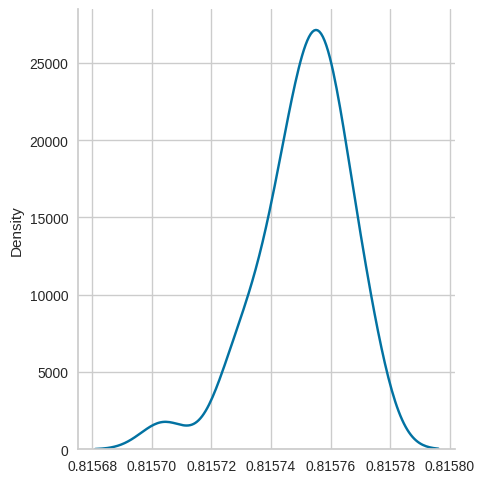

In [226]:
sns.displot(result_polynomial_30, kind = 'kde')


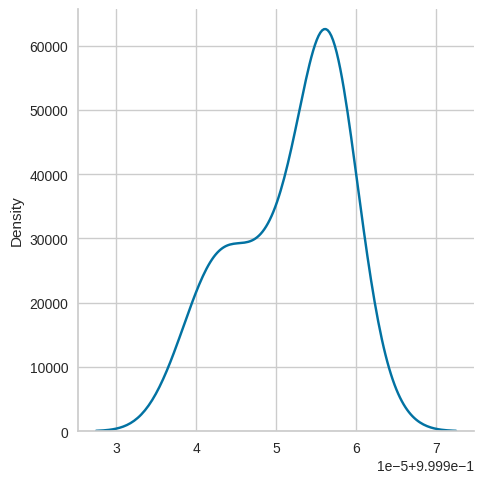

In [227]:
sns.displot(result_decision_tree_30, kind = 'kde')


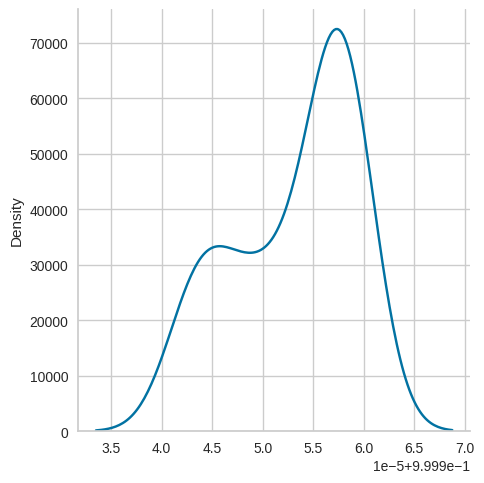

In [228]:
sns.displot(result_random_forest_30, kind = 'kde')


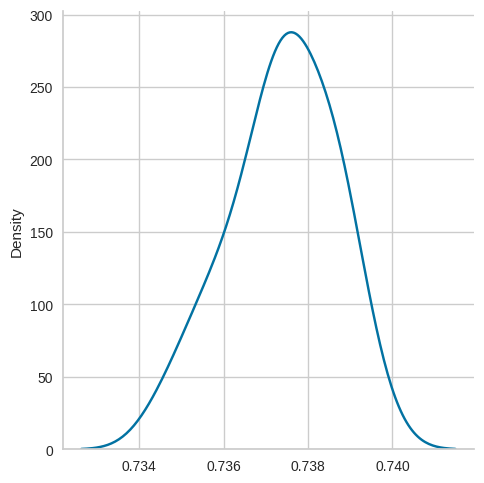

In [229]:
sns.displot(result_neural_network_30, kind = 'kde')


 **Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [230]:
# se p < alpha (0.05), os dados dos algoritmos são diferentes
_, p = f_oneway(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
p


np.float64(1.529539591641504e-263)

In [231]:
result_algorithm_30 = {'accuracy': np.concatenate([result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}


In [232]:
results_test_30_df = pd.DataFrame(result_algorithm_30)
results_test_30_df


,accuracy,algorithm
0,0.815768,polynomial
1,0.815755,polynomial
2,0.815772,polynomial
3,0.815773,polynomial
4,0.815757,polynomial
...,...,...
115,0.735835,neural_network
116,0.739023,neural_network
117,0.737063,neural_network
118,0.737519,neural_network


In [233]:
compare_algorithm_30 = MultiComparison(results_test_30_df['accuracy'], results_test_30_df['algorithm'])


In [234]:
statistical_test_30 = compare_algorithm_30.tukeyhsd()
print(statistical_test_30)


        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------
 decision_tree neural_network  -0.2626   0.0  -0.263 -0.2621   True
 decision_tree     polynomial  -0.1842   0.0 -0.1846 -0.1838   True
 decision_tree  random_forest      0.0   1.0 -0.0004  0.0004  False
neural_network     polynomial   0.0784   0.0  0.0779  0.0788   True
neural_network  random_forest   0.2626   0.0  0.2621   0.263   True
    polynomial  random_forest   0.1842   0.0  0.1838  0.1846   True
-------------------------------------------------------------------


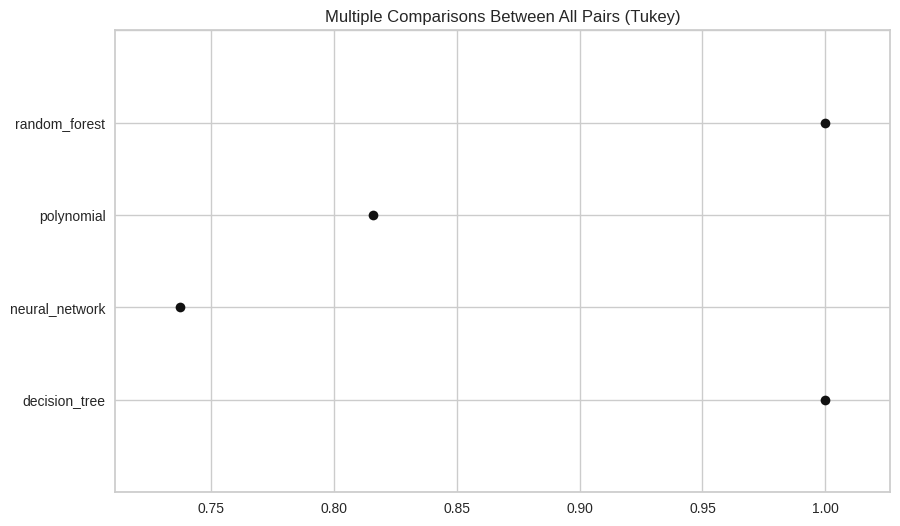

In [235]:
statistical_test_30.plot_simultaneous();


 **Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [236]:
# Conduct the Kruskal-Wallis Test
result_KW_test_30 = stats.kruskal(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
print (result_KW_test_30)


KruskalResult(statistic=np.float64(100.76584022038571), pvalue=np.float64(1.0637022593489887e-21))


/tmp/ipykernel_6428/854090141.py:2: DeprecationWarning: Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  result_KW_test_30 = stats.kruskal(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)


In [237]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp


In [238]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
data_Nemenyi_30 = np.array([result_polynomial_30, result_decision_tree_30, result_random_forest_30,result_neural_network_30])
result_Nemenyi_test_30 = sp.posthoc_nemenyi_friedman(data_Nemenyi_30.T)
print (result_Nemenyi_test_30)


          0             1             2             3
0  1.000000  8.334217e-04  1.191036e-06  1.435777e-02
1  0.000833  1.000000e+00  4.992973e-01  6.276335e-11
2  0.000001  4.992973e-01  1.000000e+00  1.221245e-15
3  0.014358  6.276335e-11  1.221245e-15  1.000000e+00


 # **Results Analysis (60)**



 Resultados com 60 testes na validação cruzada

In [239]:
#result_decision_tree3 = [0.999943146521737, 0.9999567872776005, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999569930634793, 0.9999570138284503, 0.9999530645177945, 0.9999638593656359, 0.9999498129770293, 0.9999570823049837, 0.9999568919139575, 0.9999493336871919, 0.9999568136593554, 0.9999569723344848, 0.9999532392503324, 0.999944578356408, 0.9999606251231302, 0.9999501405949642, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999496247625833, 0.9999566901024277, 0.9999548086058194, 0.9999588800396724, 0.9999567432581535, 0.9999552588619194, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.9999571646851584, 0.9999588468938274, 0.9999569655109679, 0.999957125477113, 0.9999408476837008, 0.9999584746326745, 0.9999531786234825, 0.9999567945582211, 0.9999566716083967, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.999955252354194, 0.9999570077318157, 0.9999568771419935, 0.9999671140709111, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941, 0.9999557360528787, 0.9999571167234583, 0.9999569505745439, 0.9999429726750684, 0.999958512178788, 0.9999572984674165, 0.9999570642572214, 0.999961330368623, 0.9999571349449123, 0.9999554082280644, 0.9999378185094763, 0.9999500675232376, 0.9999569457381565, 0.9999413850429638, 0.9999552568565612, 0.9999570055446872, 0.9999580692991582, 0.9999583352336417, 0.9999552262146996, 0.9999444287736035, 0.9999478816580336, 0.9999569347527167, 0.9999448375876853, 0.9999599752743655, 0.9999571451325142, 0.999939788728778, 0.9999451890616221, 0.9999571273877024, 0.9999570628953682, 0.999958689591903, 0.999944562318014, 0.9999588894050524, 0.9999569979587098, 0.9999412360612411, 0.999956535869825, 0.9999569289461896, 0.999957095122906, 0.9999420241075754, 0.9999553588622783, 0.9999571040669263, 0.9999547519672074, 0.9999360328402946, 0.9999535847482168, 0.9999567156244981, 0.999957211009581, 0.9999710114397026, 0.9999574472225208, 0.9999569174841492, 0.9999569676132595, 0.9999671431959035, 0.9999553496264337, 0.9999569584436709, 0.9999555636774042, 0.9999583450505911, 0.9999570377716935, 0.9999498153105669, 0.9999519782955121, 0.9999463440773606, 0.9999571288973117, 0.9999569109199575]
result_polynomial_60 = [0.8165713273817718, 0.8165665923950855, 0.8165817936971588, 0.8165786898565286, 0.816621698737488, 0.8165949909316341, 0.816599894556442, 0.816598019822872, 0.816602543484182, 0.8166446683849491, 0.8166176632781763, 0.8165890657342212, 0.8166057532335378, 0.8166118436677071, 0.8165997034202824, 0.81656728445386, 0.8165976760938472, 0.8165475264359136, 0.8166122102911368, 0.8166073777434088, 0.8166013266071788, 0.8165843712539847, 0.816562679449961, 0.8165785093695323, 0.8165967921824315, 0.8166114974365621, 0.816586452159697, 0.8166035233999807, 0.8166026073129771, 0.8165848681297246, 0.8166424272148612, 0.816571220957955, 0.8165267038220391, 0.8165895018697687, 0.8166114881136898, 0.8165847895807646, 0.8165851114662081, 0.8165751782793704, 0.8166180373910211, 0.8166038985496293, 0.8166003489750105, 0.8166013902923235, 0.8166011611414986, 0.8165902253098784, 0.816574191602332, 0.8165911658013982, 0.8166317919515088, 0.8165914927505823, 0.8166096096375234, 0.8165631465081479, 0.8165706345224497, 0.8165770236057069, 0.8166157627122352, 0.816592125031153, 0.8165984921152962, 0.8165904746721517, 0.8165668473323394, 0.8165772932193586, 0.816602318328632, 0.8166388321069145]
#result_polynomial3 =[0.6265713273817718, 0.6265665923950855, 0.6265817936971588, 0.6265786898565286, 0.626621698737488, 0.6265949909316341, 0.626599894556442, 0.626598019822872, 0.626602543484182, 0.6266446683849491, 0.6266176632781763, 0.6265890657342212, 0.6266057532335378, 0.6266118436677071, 0.6265997034202824, 0.62656728445386, 0.6265976760938472, 0.6265475264359136, 0.6266122102911368, 0.6266073777434088, 0.6266013266071788, 0.6265843712539847, 0.626562679449961, 0.6265785093695323, 0.6265967921824315, 0.6266114974365621, 0.626586452159697, 0.6266035233999807, 0.6266026073129771, 0.6265848681297246, 0.6266424272148612, 0.626571220957955, 0.6265267038220391, 0.6265895018697687, 0.6266114881136898, 0.6265847895807646, 0.6265851114662081, 0.6265751782793704, 0.6266180373910211, 0.6266038985496293, 0.6266003489750105, 0.6266013902923235, 0.6266011611414986, 0.6265902253098784, 0.626574191602332, 0.6265911658013982, 0.6266317919515088, 0.6265914927505823, 0.6266096096375234, 0.6265631465081479, 0.6265706345224497, 0.6265770236057069, 0.6266157627122352, 0.626592125031153, 0.6265984921152962, 0.6265904746721517, 0.6265668473323394, 0.6265772932193586, 0.626602318328632, 0.6266388321069145]
result_decision_tree_60 = [0.9999484660048126, 0.9999575010454931, 0.9999567711554782, 0.9999459475921968, 0.9999431776258364, 0.9999454979281228, 0.9999441591309097, 0.9999566106554678, 0.9999589161196557, 0.9999554652614062, 0.9999593506338247, 0.9999533926484968, 0.9999571311661903, 0.9999531501045335, 0.9999444461071224, 0.9999566529019479, 0.9999570212646528, 0.9999505401933486, 0.9999463447276671, 0.9999569905651731, 0.9999528929961607, 0.9999529490836471, 0.9999589221141276, 0.9999440689644524, 0.999944403102964, 0.9999581540888871, 0.9999549734450014, 0.9999563793575847, 0.9999568835985782, 0.9999576338999013, 0.9999564554221614, 0.9999532592462484, 0.999959003338821, 0.9999530092639262, 0.9999457374645555, 0.9999555733191936, 0.9999538292457016, 0.9999550081865743, 0.9999581008680336, 0.9999429560760944, 0.9999544420985235, 0.9999526526028235, 0.9999581332573835, 0.9999566396116097, 0.9999576089187843, 0.9999464595025828, 0.9999561029636995, 0.9999537621963628, 0.9999586271902089, 0.9999590416701383, 0.9999584663013683, 0.999953855811748, 0.9999552017614324, 0.9999587282904144, 0.9999574815173121, 0.9999621830831478, 0.9999577112181928, 0.9999544842460513, 0.9999585364678463, 0.999955832232341]
result_random_forest_60 = [0.9999448391620099, 0.999958514264906, 0.9999570673775097, 0.9999447390226738, 0.9999359393511884, 0.9999446619893331, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.999962184416941, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.999955095841613, 0.9999552842285337, 0.9999532392503324, 0.999946270243085, 0.9999572388707858, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999513167071434, 0.9999583736603336, 0.9999581923852989, 0.999957198031462, 0.9999567432581535, 0.9999569619861182, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.999955457385545, 0.9999571417464814, 0.9999552711318426, 0.999957125477113, 0.9999391487599144, 0.9999567693330587, 0.9999531786234825, 0.9999567945582211, 0.9999583901983813, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.9999569663845259, 0.9999570077318157, 0.9999568771419935, 0.999965424267075, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941]
result_neural_network_60 = [0.7355617883876759, 0.7386313406242563, 0.7367214372779667, 0.7357803049451711, 0.7382879919537916, 0.7365781398463648, 0.7367255239155929, 0.7370336152303343, 0.7365604132389272, 0.735800300954838, 0.7360559201189976, 0.736265520906961, 0.7387531842423051, 0.736735217896185, 0.7388923555448701, 0.7377627489434608, 0.7376969551124896, 0.7373704212333626, 0.7357588697710584, 0.7375725395632089, 0.738004462501894, 0.736087304299287, 0.7352010377272595, 0.7387107806799057, 0.7379369373362578, 0.7381341363237767, 0.7370678465074582, 0.7345779906110821, 0.7359376051620564, 0.7368517509780408, 0.7356828685558556, 0.7372504075600227, 0.735954912903826, 0.7357766757010071, 0.7365270477706933, 0.7372907491940432, 0.7359776352421746, 0.7372713808969119, 0.7383911549839496, 0.7375136205254523, 0.7371898808660311, 0.7363794295379793, 0.7360060835367299, 0.7379240661872748, 0.7377362967853992, 0.737686684226016, 0.7368081228451133, 0.7373484431844067, 0.7340633263903394, 0.737081753332193, 0.7361777030162584, 0.7362476446227569, 0.735839653029098, 0.7374622778292671, 0.7366017172018027, 0.7378232419316892,  0.7390012362141941, 0.7392012362141941, 0.7394012362141941, 0.73960012362141941]


In [240]:
results_60_df = pd.DataFrame({'Polynomial': result_polynomial_60, 'Decision Tree': result_decision_tree_60, 'Random Forest': result_random_forest_60, "Neural Network": result_neural_network_60})
results_60_df


,Polynomial,Decision Tree,Random Forest,Neural Network
0,0.816571,0.999948,0.999945,0.735562
1,0.816567,0.999958,0.999959,0.738631
2,0.816582,0.999957,0.999957,0.736721
3,0.816579,0.999946,0.999945,0.735780
4,0.816622,0.999943,0.999936,0.738288
5,0.816595,0.999945,0.999945,0.736578
6,0.816600,0.999944,0.999941,0.736726
7,0.816598,0.999957,0.999955,0.737034
8,0.816603,0.999959,0.999957,0.736560
9,0.816645,0.999955,0.999953,0.735800


In [241]:
results_60_df.describe()


,Polynomial,Decision Tree,Random Forest,Neural Network
count,60.000000,60.000000,60.000000,60.000000
mean,0.816594,0.999954,0.999953,0.737038
std,0.000022,0.000005,0.000006,0.001188
min,0.816527,0.999943,0.999936,0.734063
25%,0.816579,0.999953,0.999951,0.736079
50%,0.816596,0.999956,0.999957,0.737051
75%,0.816604,0.999958,0.999957,0.737778
max,0.816645,0.999962,0.999965,0.739600


In [242]:
# Variance
results_60_df.var()


,0
Polynomial,4.763208e-10
Decision Tree,2.499887e-11
Random Forest,3.930091e-11
Neural Network,1.411314e-06


In [243]:
# Coefficient of variation (%)
(results_60_df.std() / results_60_df.mean()) * 100


,0
Polynomial,0.002673
Decision Tree,0.000500
Random Forest,0.000627
Neural Network,0.161184


 # **Statistical Tests (60)**

 **Test of normality of results**

In [244]:
alpha = 0.05
shapiro (result_polynomial_60), shapiro (result_decision_tree_60), shapiro (result_random_forest_60), shapiro (result_neural_network_60)


(ShapiroResult(statistic=np.float64(0.9800340099378327), pvalue=np.float64(0.4299762194813227)),
 ShapiroResult(statistic=np.float64(0.8589086684716053), pvalue=np.float64(5.636781894631199e-06)),
 ShapiroResult(statistic=np.float64(0.8305837364471894), pvalue=np.float64(8.526906746951769e-07)),
 ShapiroResult(statistic=np.float64(0.9867260211900024), pvalue=np.float64(0.7591215438801651)))

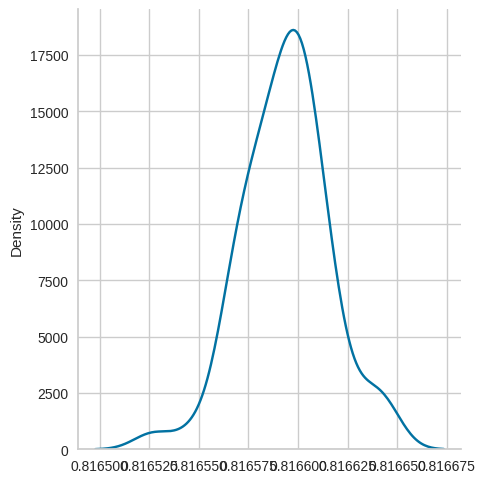

In [245]:
sns.displot(result_polynomial_60, kind = 'kde')


/tmp/ipykernel_6428/75844255.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_polynomial_60, color="dodgerblue", label="Compact",)


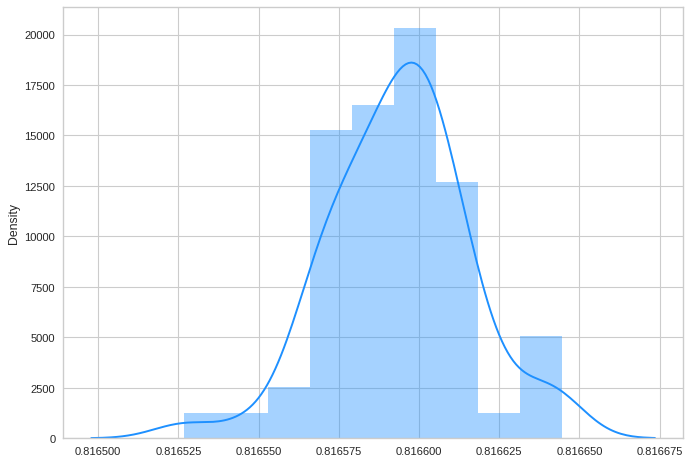

In [246]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_polynomial_60, color="dodgerblue", label="Compact",)
plt.show()


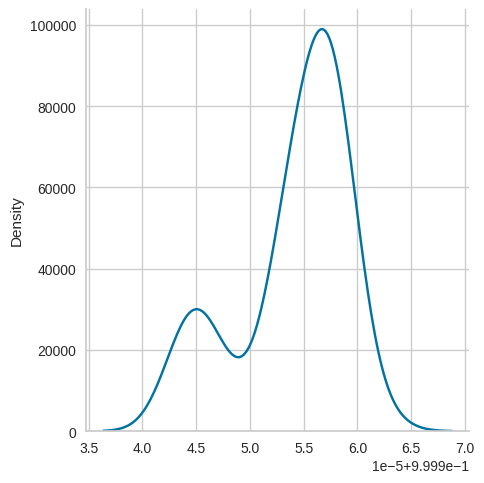

In [247]:
sns.displot(result_decision_tree_60, kind = 'kde')


/tmp/ipykernel_6428/3097505787.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_decision_tree_60, color="dodgerblue", label="Compact",)


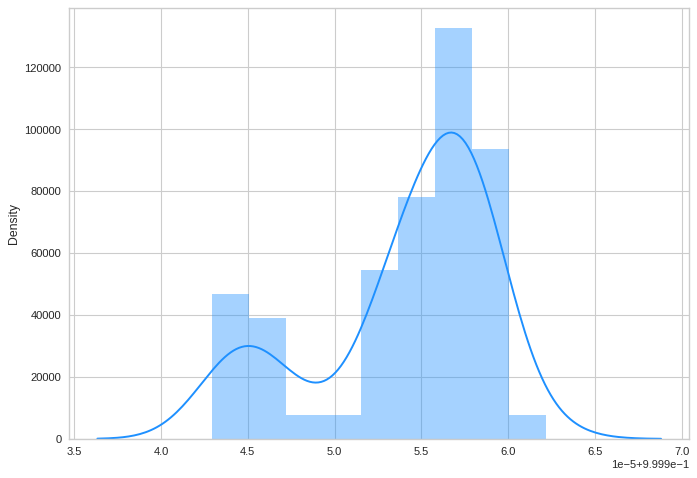

In [248]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_decision_tree_60, color="dodgerblue", label="Compact",)
plt.show()


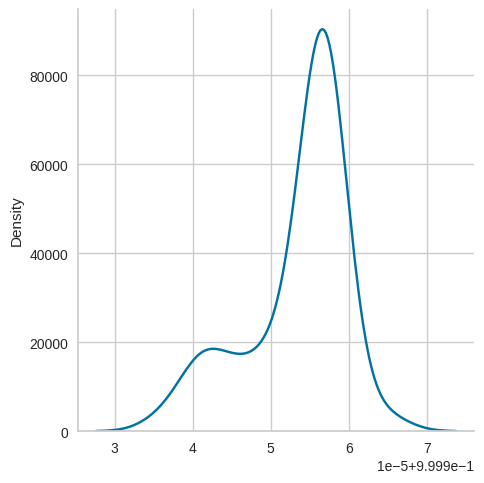

In [249]:
sns.displot(result_random_forest_60, kind = 'kde')


/tmp/ipykernel_6428/3182858428.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_random_forest_60, color="dodgerblue", label="Compact",)


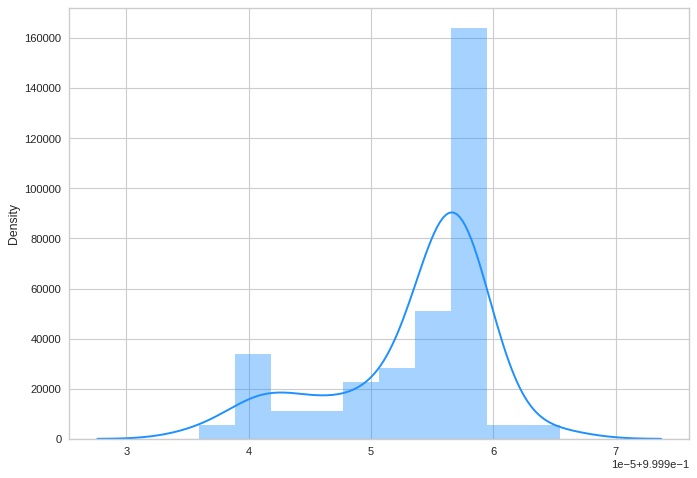

In [250]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_random_forest_60, color="dodgerblue", label="Compact",)
plt.show()


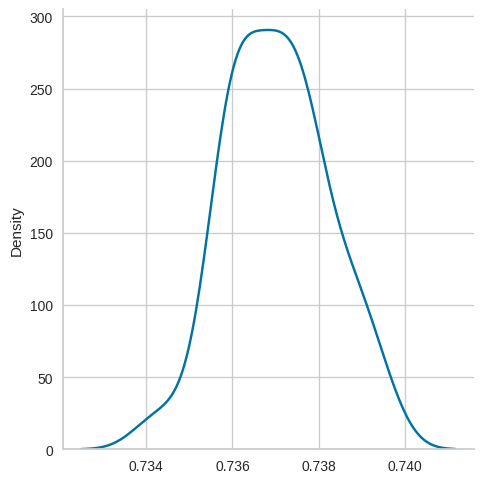

In [251]:
sns.displot(result_neural_network_60, kind = 'kde')


/tmp/ipykernel_6428/1042375144.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(result_neural_network_60, color="dodgerblue", label="Compact",)


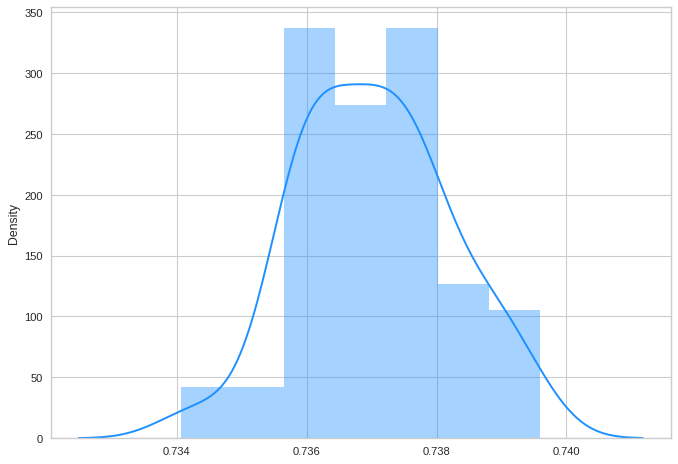

In [252]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_neural_network_60, color="dodgerblue", label="Compact",)
plt.show()


 **Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [253]:
# se p < alpha (0.05), há diferença estatística entre os algoritmos
_, p = f_oneway(result_polynomial_60, result_decision_tree_60,
                result_random_forest_60, result_neural_network_60)
print(p)


0.0


In [254]:
result_algorithm_60 = {'accuracy': np.concatenate([result_polynomial_60, result_decision_tree_60, result_random_forest_60, result_neural_network_60]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree', 'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network', 'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}


In [255]:
results_test_60_df = pd.DataFrame(result_algorithm_60)
results_test_60_df


,accuracy,algorithm
0,0.816571,polynomial
1,0.816567,polynomial
2,0.816582,polynomial
3,0.816579,polynomial
4,0.816622,polynomial
...,...,...
235,0.737823,neural_network
236,0.739001,neural_network
237,0.739201,neural_network
238,0.739401,neural_network


In [256]:
compare_algorithm_60 = MultiComparison(results_test_60_df['accuracy'], results_test_60_df['algorithm'])


In [257]:
statistical_test_60 = compare_algorithm_60.tukeyhsd()
print(statistical_test_60)


        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1         group2     meandiff p-adj  lower   upper  reject
-------------------------------------------------------------------
 decision_tree neural_network  -0.2629   0.0 -0.2632 -0.2626   True
 decision_tree     polynomial  -0.1834   0.0 -0.1836 -0.1831   True
 decision_tree  random_forest     -0.0   1.0 -0.0003  0.0003  False
neural_network     polynomial   0.0796   0.0  0.0793  0.0798   True
neural_network  random_forest   0.2629   0.0  0.2626  0.2632   True
    polynomial  random_forest   0.1834   0.0  0.1831  0.1836   True
-------------------------------------------------------------------


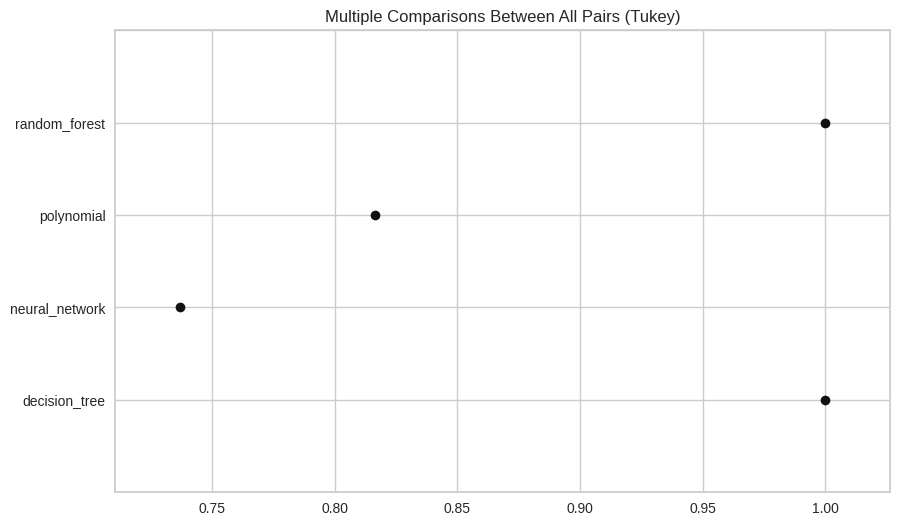

In [258]:
statistical_test_60.plot_simultaneous();


 **Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [259]:
# Conduct the Kruskal-Wallis Test
result_KW_test_60 = stats.kruskal(result_polynomial_60, result_decision_tree_60,
                                  result_random_forest_60, result_neural_network_60)
print (result_KW_test_60)


KruskalResult(statistic=np.float64(201.67313969571228), pvalue=np.float64(1.8349992749716806e-43))


/tmp/ipykernel_6428/3508599005.py:2: DeprecationWarning: Please import `kruskal` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  result_KW_test_60 = stats.kruskal(result_polynomial_60, result_decision_tree_60,


In [260]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp


In [261]:
# Conduct the Nemenyi post-hoc test
data_Nemenyi_60 = np.array([result_polynomial_60, result_decision_tree_60,
                            result_random_forest_60, result_neural_network_60])
result_Nemenyi_test_60 = sp.posthoc_nemenyi_friedman(data_Nemenyi_60.T)
print (result_Nemenyi_test_60)

              0             1             2        3
0  1.000000e+00  1.108930e-10  1.109491e-08  0.00013
1  1.108930e-10  1.000000e+00  8.943255e-01  0.00000
2  1.109491e-08  8.943255e-01  1.000000e+00  0.00000
3  1.298172e-04  0.000000e+00  0.000000e+00  1.00000
